<a href="https://colab.research.google.com/github/giseleismail/Neur265/blob/main/Coding_Homework_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Gisele Ismail
*Neur265*

**04/09/2026**

In [55]:
#2. import modules
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

In [33]:
#3. import csv
fear_traces = np.loadtxt('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/fear_conditioning_traces_hw8.csv', delimiter = ',')
extinction_predictors = np.loadtxt('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/extinction_predictors_hw8.csv', delimiter = ',')
shock_index = np.loadtxt('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/shock_index.csv', delimiter = ',').astype(int)
tone_index = np.loadtxt('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/tone_index.csv', delimiter = ',').astype(int)


In [34]:
#5. conditioning_traces and extinction_traces variables
conditioning_traces = fear_traces[:10458, :]
extinction_traces = fear_traces[10458:, :]


In [35]:
#6. size of conditioning & extinction traces
print(conditioning_traces.shape)
print(extinction_traces.shape)

(10458, 63)
(14210, 63)


In [89]:
#7. time_conditioning and time_extinction variables
time_conditioning = np.linspace(0, 10457/15, 10458)
time_extinction = np.linspace(0, 14209/15, 14210)

print(14210/15)
print((14210/15)/60)

print(10458/15)
print((10458/15)/60)

947.3333333333334
15.78888888888889
697.2
11.620000000000001


amount of ROI's: **63**

total length in time (*conditioning*): **697.2 seconds, 11.62 minutes**

total length in time (*extinction*): **947.3 seconds, 15.78 minutes**

Text(0, 0.5, 'Fluorescence')

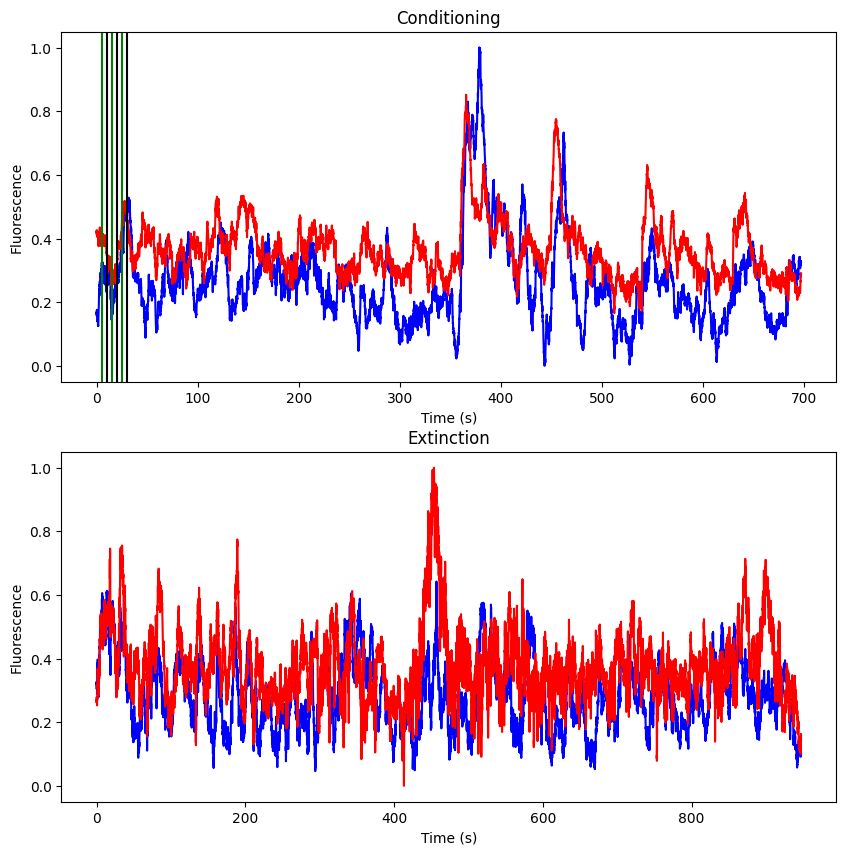

In [37]:
#9. two subplots, conditioning traces & extinction traces
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

axes[0].plot(time_conditioning, conditioning_traces[:, 0], color='blue')
axes[0].plot(time_conditioning, conditioning_traces[:, 1], color='red')

shock_times = [10, 20, 30]
tone_times  = [5, 15, 25]

for t in shock_times:
    axes[0].axvline(t, color='black')

for t in tone_times:
    axes[0].axvline(t, color='green')

axes[0].set_title("Conditioning")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Fluorescence")

axes[1].plot(time_extinction, extinction_traces[:, 0], color='blue')
axes[1].plot(time_extinction, extinction_traces[:, 1], color='red')

axes[1].set_title("Extinction")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Fluorescence")


for conditioning, ROI1 and ROI2 are pretty similar in structure, they have peaks and dips at the same time. ROI 2 seems to be a bit higher and more active.

for extinction, the traces are more noisy and less event-locked. ROI1 and ROI2 are still similar in structure, but ROI2 is still generally higher.

the 2 ROIs are not independed they are fluctuating in a similar way. Conditioning shows stronger structure and clearer event-locked activity, while extinction shows a weaker version of the same pattern.

In [73]:
#12. predictors_conditioning variable with shock & tone onset.

shock_array = np.zeros(10458)
for i in range(10458):
  if i >= (shock_index[0]-15)*15 and i <= (shock_index[0]+30)*15:
    shock_array[i] = 1
  elif i>= (shock_index[1]-15)*15 and i <= (shock_index[1]+30)*15:
    shock_array[i] = 1
  elif i>= (shock_index[2]-15)*15 and i <= (shock_index[2]+30)*15:
    shock_array[i] = 1
  else:
    shock_array[i] = 0

tone_array = np.zeros(10458)
for i in range(10458):
  if i >= (tone_index[0]-15)*15 and i <= (tone_index[0]+30)*15:
    tone_array[i] = 1
  elif i>= (tone_index[1]-15)*15 and i <= (tone_index[1]+30)*15:
    tone_array[i] = 1
  elif i>= (tone_index[2]-15)*15 and i <= (tone_index[2]+30)*15:
    tone_array[i] = 1
  else:
    tone_array[i] = 0

/tmp/ipykernel_2796/1545370501.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0, 0.5, 'Proportion of ROIs')

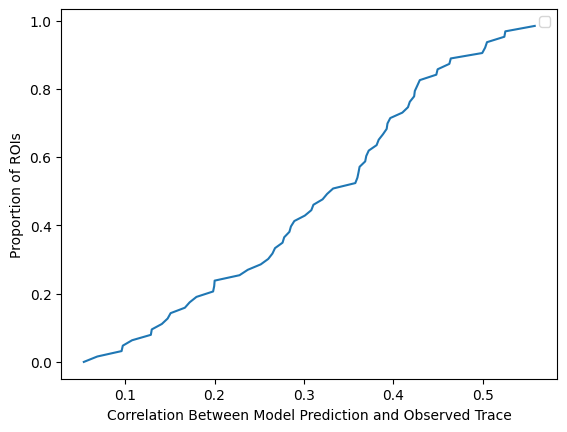

In [84]:
#13. Create r_model_conditioning and run for loop, new coefficient r_index_conditioning

from pandas import DataFrame as df
import statsmodels.api as sm
from statsmodels.genmod.families import Poisson
from statsmodels.genmod.families.links import identity, log
from scipy.stats import chi2
from statsmodels.distributions.empirical_distribution import ECDF

predictors_conditioning = df({'Intercept': np.ones(10458),'shock onset': shock_array,'tone onset': tone_array})

#predictors_conditioning['shock onset'] = shock_array
r_index_conditioning = np.zeros(conditioning_traces.shape[1])

for i in range(conditioning_traces.shape[1]):
  trace_temp = conditioning_traces[:,i]
  model = sm.GLM(trace_temp, predictors_conditioning, family=Poisson())
  model_results = model.fit()
  predicted_trace = model_results.predict()

  r = pearsonr(trace_temp, predicted_trace)
  r_index_conditioning[i] = r.statistic

plt.plot(np.sort(r_index_conditioning), np.linspace(0, 1, len(r_index_conditioning), endpoint=False))
plt.legend()
plt.xlabel('Correlation Between Model Prediction and Observed Trace')
plt.ylabel('Proportion of ROIs')

/tmp/ipykernel_2796/2459668812.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0, 0.5, 'Proportion of ROIs')

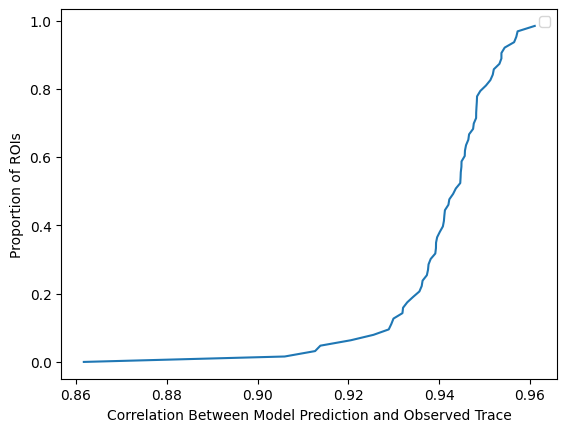

In [83]:
#14. extinction predictor
extinction_predictors = df(data={'Intercept': np.ones_like(tone_array), 'tone onset': tone_array})
r_index_extinction = np.zeros(extinction_traces.shape[1])

for i in range(extinction_traces.shape[1]):
  trace_temp = extinction_traces[:,i]
  model = sm.GLM(trace_temp, extinction_traces, family=Poisson())
  model_results = model.fit()
  predicted_trace = model_results.predict()

  r = pearsonr(trace_temp, predicted_trace)
  r_index_extinction[i] = r.statistic

plt.plot(np.sort(r_index_extinction), np.linspace(0, 1, len(r_index_extinction), endpoint=False))
plt.legend()
plt.xlabel('Correlation Between Model Prediction and Observed Trace')
plt.ylabel('Proportion of ROIs')


In [78]:
#15. correlate conditioning and extinction variables
r, p = pearsonr(r_index_conditioning, r_index_extinction)
print(r, p)

0.2093158566558247 0.09967775344396576


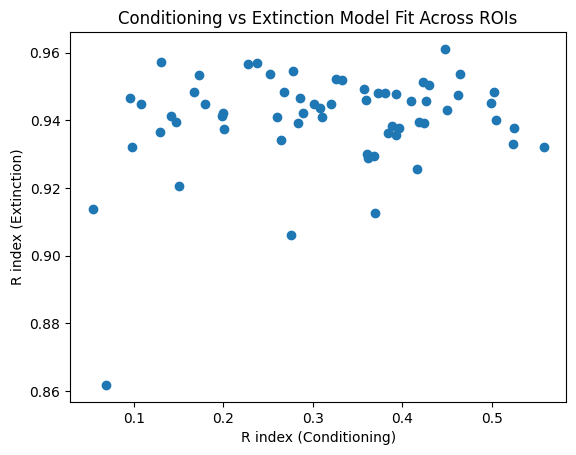

In [79]:
#16. scatterplot with conditioning on x-axis and extinction on y-axis

plt.scatter(r_index_conditioning, r_index_extinction)

plt.xlabel('R index (Conditioning)')
plt.ylabel('R index (Extinction)')
plt.title('Conditioning vs Extinction Model Fit Across ROIs')

plt.show()

r=0.21 and p=0.1, there is a very weak positive relationship & is not statistically significant between conditioning and extinction model. i dont think cells that respond strongly to shock and tone onset during conditioning sessions will also respond strongly to tone onset during the extinction session.